In [212]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [213]:
DT = 2
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [214]:

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data_bin/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)']

    # Sort by time within each batch
    return df



path = f'test_data_50beta_20p'

data = read_data(path)

#rename columns
data.columns = ['u_par','C','t','V_t','I','Rx','u','ocv']

data['u'] = data['u'] * -1e6
data['Rx'] = data['Rx'] * -1e-6
data['I'] = data['I'] * -1.
data['eta'] = data['V_t'] - data['ocv']


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69974/4124929483.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [215]:
# Add numeric trajectory id for each unique (C, u_par) pair
data['trajectory'] = data.groupby(['C', 'u_par'], sort=False).ngroup()

# Optional lookup table (one row per trajectory)
trajectory_lookup = (
    data[['C', 'u_par', 'trajectory']]
    .drop_duplicates()
    .sort_values('trajectory')
    .reset_index(drop=True)
)

print(trajectory_lookup)
print(f"Number of trajectories: {trajectory_lookup['trajectory'].nunique()}")

      C  u_par  trajectory
0   2.8    0.6           0
1   0.8    2.2           1
2   2.3   24.2           2
3   1.8   25.8           3
4   2.0   15.5           4
5   4.3   29.7           5
6   3.2   17.7           6
7   4.9    7.8           7
8   1.1   27.0           8
9   3.7   19.2           9
10  4.7    3.3          10
11  3.3    4.7          11
12  2.3   11.2          12
13  1.4   10.0          13
14  0.7   13.2          14
15  3.9   21.4          15
16  4.2   23.5          16
17  3.6    6.7          17
18  2.6   14.6          18
19  1.3   20.1          19
Number of trajectories: 20


In [216]:
# Add finite-difference columns with the same length as `data`
dV = np.diff(data['V_t'].to_numpy())[:-1] / DT
dRx = np.diff(data['Rx'].to_numpy())[:-1] / DT

if len(dV) > 0:
    for i in range(2):
        dV = np.append(dV, dV[-1])
        dRx = np.append(dRx, dRx[-1])
else:
    dV = np.array([0.0])
    dRx = np.array([0.0])

data['dV_t'] = dV
data['dRx'] = dRx

data.head()


,u_par,C,t,V_t,I,Rx,u,ocv,eta,trajectory,dV_t,dRx
0,0.6,2.8,0,4.219347,13.939003,45.848423,-0.862395,4.324995,-0.105648,0,-0.026816,-0.599056
1,0.6,2.8,2,4.165714,13.939003,44.650311,-0.862395,4.320263,-0.154549,0,-0.008908,-0.599655
2,0.6,2.8,4,4.147898,13.939003,43.451001,-0.862395,4.315527,-0.167629,0,-0.007053,-0.599655
3,0.6,2.8,6,4.133791,13.939003,42.251690,-0.862395,4.310790,-0.176999,0,-0.005853,-0.599655
4,0.6,2.8,8,4.122085,13.939003,41.052379,-0.862395,4.306053,-0.183968,0,-0.005039,-0.599655


# Plotting data

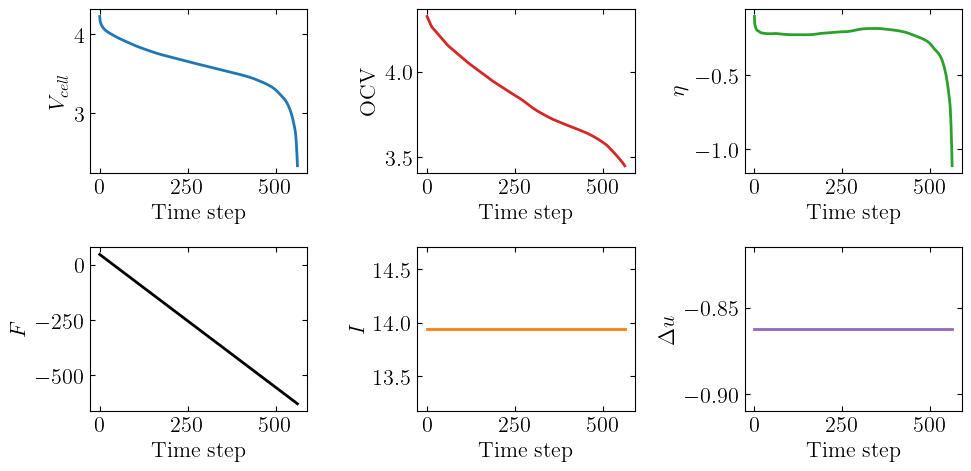

In [217]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V_t'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['ocv'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('OCV')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['Rx'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')
#ax[].plot(data['ocv'][plot_idx], lw = 2,color = colors[4])

plt.tight_layout()
plt.show()

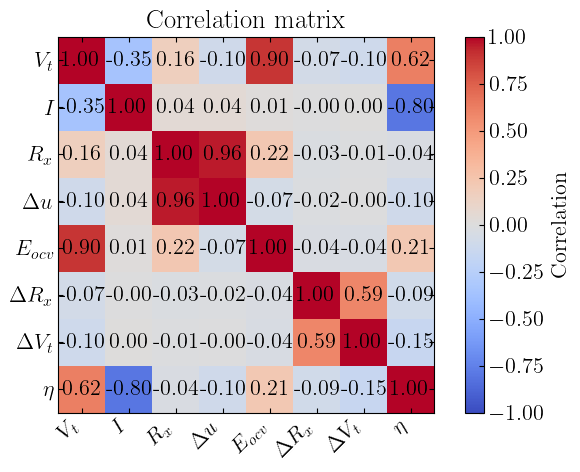

In [218]:
# Correlation matrix for current signals in this batch

X = data[['V_t','I','Rx','u_par','ocv','dRx','dV_t','eta']].values
feature_names = ['$V_t$','$I$','$R_x$',r'$\Delta u$','$E_{ocv}$',r'$\Delta R_x$',r'$\Delta V_t$',r'$\eta$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(7, 5))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

53.16 MN/µm


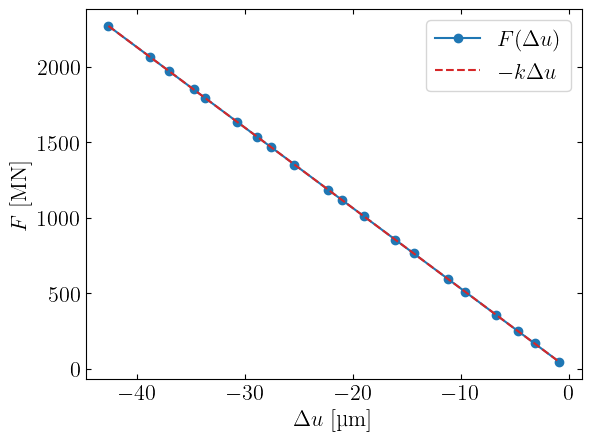

In [219]:
traj = 0
#plt.plot(data['u'][data['trajectory'] == traj], data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u')['Rx']


first_rx = data.groupby('u')['Rx'].first()
k = abs(first_rx / (data.groupby('u')['u'].first()))
plt.plot(data.groupby('u')['u'].first(), first_rx, 'o-', color = colors[0], label = r'$F(\Delta u)$')
plt.plot(data.groupby('u')['u'].first(), -k * data.groupby('u')['u'].first(), '--', color = colors[1], label = r'$-k\Delta u$')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$F$ [MN]')
plt.legend()
print(f'{k.values[0]:.2f} MN/µm')


Text(0, 0.5, '$F$ [MN]')

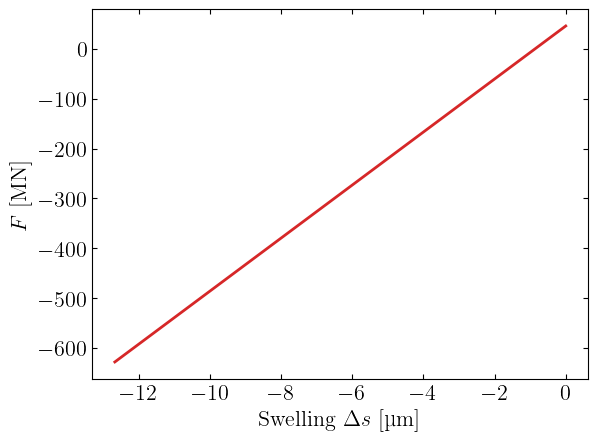

In [220]:
ds = data['Rx'][data['trajectory'] == traj] / k.values[0] + data['u'][data['trajectory'] == traj] 

plt.plot(ds,data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel(r'Swelling $\Delta s$ [µm]')
plt.ylabel(r'$F$ [MN]')

Text(0, 0.5, 'OCV [V]')

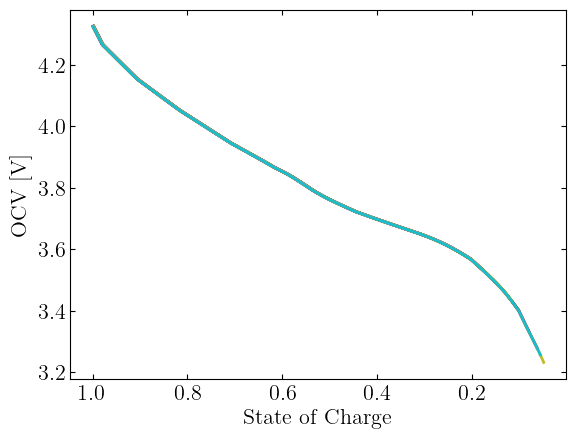

In [221]:

def SOC(Z_init, I, Q = Q0, dt = DT):
    return Z_init - I * dt / Q

for traj in data['trajectory'].unique():    
    soc = np.ones(len(data['I'][data['trajectory'] == traj]) + 1) * 1.0
    for i in 1 + np.arange(len(data['I'][data['trajectory'] == traj])):
        soc[i] = SOC(soc[i-1], data['I'][data['trajectory'] == traj].iloc[i-1])

    plt.plot(soc[1:],data['ocv'][data['trajectory'] == traj], lw = 2, label = f'I = {(data['I'][data['trajectory'] == traj].values)[0]} ')
plt.xlabel('State of Charge')
plt.gca().invert_xaxis()
plt.ylabel('OCV [V]')

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

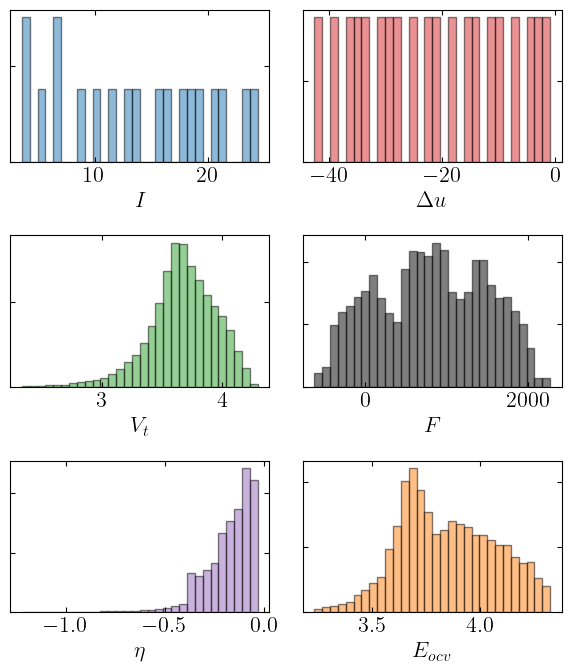

In [222]:
f, ax = plt.subplots(3,2,figsize=(6, 7))
ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u']) , bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['Rx']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['ocv'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['eta']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$')
ax[0,1].set_xlabel(r'$\Delta u$')
ax[1,0].set_xlabel('$V_t$')
ax[1,1].set_xlabel('$F$')
ax[2,1].set_xlabel('$E_{ocv}$')
ax[2,0].set_xlabel(r'$\eta$')
#ax[2,0].set_xlabel('$E_{ocv}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

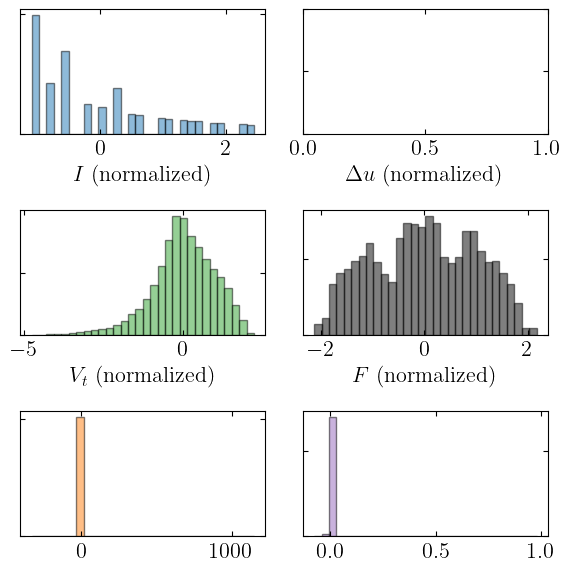

In [223]:
stats = {}

def compute_stats(x, name):
    if name == 'R':
        stats[name] = (np.min(x), np.max(x))
    else:
        stats[name] = (np.mean(x), np.std(x))
    return stats[name]
stats['I'] = compute_stats(data['I'], 'I')
stats['V_t'] = compute_stats(data['V_t'], 'V_t')
stats['u'] = compute_stats(data['u'], 'u')
stats['Rx'] = compute_stats(data['Rx'], 'Rx')
stats['ocv'] = compute_stats(data['ocv'], 'ocv')





def normalize(x, name, stats = stats):
    #if name == 'R':
    return (x - stats[name][0]) / stats[name][1]
    #else: 
    #    return (x - stats[name][0]) / (stats[name][1] - stats[name][0])

    
def denormalize(x, name, stats=stats):
    #if name == 'R':
    return x * stats[name][1] + stats[name][0]
    #else:   
    #    return x * (stats[name][1] - stats[name][0]) + stats[name][0]
    
data['I_norm'] = normalize(data['I'], 'I')
data['V_t_norm'] = normalize(data['V_t'], 'V_t')
data['u_norm'] = normalize(data['u'], 'u')
data['Rx_norm'] = normalize(data['Rx'], 'Rx')
data['ocv_norm'] = normalize(data['ocv'], 'ocv')



f, ax = plt.subplots(3,2,figsize=(6, 6))
ax[0,0].hist(data['I_norm'], bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t_norm'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(data['Rx_norm'], bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist(data['dRx'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['dV_t'], bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$ (normalized)')
ax[0,1].set_xlabel(r'$\Delta u$ (normalized)')
ax[1,0].set_xlabel('$V_t$ (normalized)')
ax[1,1].set_xlabel('$F$ (normalized)')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

In [224]:
N_trajs = len(data['trajectory'].unique())


# test_inds = data['trajectory'] >= int(N_trajs * 0.8)

# print(test_inds.sum(), 'test samples')

# X = np.zeros((len(data) +1, 3))
# y = np.zeros((len(data) + 1,2))
# print(len(data[['V_t']].values))
# traj_len0 = 0

# for traj_ids in range(0, N_trajs):
#     traj_len1 = traj_len0 + len(data[data['trajectory'] == traj_ids]) - 1
#     X[traj_len0:traj_len1,...] = data[['I','u', 'ocv']][data['trajectory'] == traj_ids].values[:]
#     y[traj_len0:traj_len1,...] = data[['V_t','Rx']][data['trajectory'] == traj_ids].values[:]

#     traj_len0 = traj_len1



X = data[['I_norm','u_norm', 'ocv_norm']].values
y = data[['V_t_norm','Rx_norm']].values

In [225]:
x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

df_train = data[data['trajectory'] <= int(N_trajs * 0.8)]
df_test = data[data['trajectory'] > int(N_trajs * 0.8)]

train_loader_flat = DataLoader(TensorDataset(x_train, y_train), shuffle=False)

Number of trajectories in train: 16 out of 20
X shape torch.Size([15406, 3])	y shape torch.Size([15406, 2])
X-train shape: torch.Size([13069, 3])	y-train shape: torch.Size([13069, 2])
X-test shape: torch.Size([2337, 3])	y-test shape: torch.Size([2337, 2])


In [226]:
''' Mk 1 '''
import torch.nn.functional as TF

def ECM_box(Ue, I, R0):
    Ue = denormalize(Ue, 'ocv')
    I = denormalize(I, 'I')
    return normalize(Ue - I * R0, 'V_t')

def Mech_box(u,s , k = k.values[0]):
    u = denormalize(u, 'u')
    s = denormalize(s, 'u')
    return normalize(-k * u + k * s, 'Rx')

class Net(nn.Module):
    def __init__(self, input_size=3, hidden_size=64): 
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        R0_raw, Fs_raw = self.net(x)[:,0], self.net(x)[:,1]

        return R0_raw, Fs_raw


model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)  

In [227]:
try: 
    print(summary(model, input_data=x_train[:2]))
except Exception as e:
    print(f"Error in model summary: {e}")

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [2]                       --
├─Sequential: 1-1                        [2, 2]                    --
│    └─Linear: 2-1                       [2, 64]                   256
│    └─ReLU: 2-2                         [2, 64]                   --
│    └─Linear: 2-3                       [2, 64]                   4,160
│    └─ReLU: 2-4                         [2, 64]                   --
│    └─Linear: 2-5                       [2, 2]                    130
├─Sequential: 1-2                        [2, 2]                    (recursive)
│    └─Linear: 2-6                       [2, 64]                   (recursive)
│    └─ReLU: 2-7                         [2, 64]                   --
│    └─Linear: 2-8                       [2, 64]                   (recursive)
│    └─ReLU: 2-9                         [2, 64]                   --
│    └─Linear: 2-10                      [2, 2]      

In [228]:
# def next_step(x, Ue, I, k, u):
#     R0_dot, F_dot = model(x)
#     R0 = R0_dot * dt + x[:,0]
#     F  = F_dot  * dt + x[:,1] 

#     Vt = ECM_box(Ue,I,R0)
#     FR = Mech_box(u,k,F)

#     return torch.stack([R0, F], dim=1), Vt, FR



def training(epochs=30):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    tot_time = 0.0
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        d_ep_loss = 0.0
        start_t = time.perf_counter()
        for x_b, y_b in train_loader_flat:
            
            I = x_b[:,0]
            u = x_b[:,1]
            Ue = x_b[:,2]
            
            R0_pred, s_pred = model(x_b)

            s_pred = s_pred

            
            y_pred = torch.stack([(ECM_box(Ue,I,R0_pred)),(Mech_box(u,s_pred))], dim=1)
            
            
            
            
            d_loss = nn.MSELoss()(y_pred, y_b)

            
            tot_loss = d_loss
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            tot_loss.backward()
            optimizer.step()
            tot_ep_loss += d_loss.item()
            d_ep_loss += d_loss.item()
        tot_last = tot_ep_loss / len(train_loader_flat)  # Average loss per batch
        d_last = d_ep_loss / len(train_loader_flat)
        end_t = time.perf_counter()

        history["loss"].append(tot_last)
        history["d_loss"].append(d_last)
        history["time per ep"].append(end_t - start_t)
        tot_time += end_t - start_t
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > 2*60:
            print("Early stopping: Total training time exceeded 3 minutes.")
            break
        print(f"Epoch {ep+1} | loss {tot_last:.3e} | time {end_t - start_t:.2f}s")

    return history

In [229]:
history = training(epochs=500)

ETA: 63.02 min
Epoch 1 | loss 2.606e-02 | time 7.56s
Epoch 2 | loss 2.422e-03 | time 7.80s
Epoch 3 | loss 4.994e-03 | time 8.57s
Epoch 4 | loss 3.558e-03 | time 7.91s
Epoch 5 | loss 2.725e-03 | time 7.90s
Epoch 6 | loss 2.032e-02 | time 7.72s
Epoch 7 | loss 8.161e-03 | time 7.43s
Epoch 8 | loss 5.400e-03 | time 7.55s
Epoch 9 | loss 6.303e-03 | time 7.46s
Epoch 10 | loss 7.022e-03 | time 7.44s
Epoch 11 | loss 3.947e-03 | time 7.45s
Epoch 12 | loss 2.175e-03 | time 7.44s
Epoch 13 | loss 2.399e-03 | time 7.46s
Epoch 14 | loss 1.503e-03 | time 7.55s
Epoch 15 | loss 8.500e-04 | time 7.42s
Early stopping: Total training time exceeded 3 minutes.


0.0011304971426065451


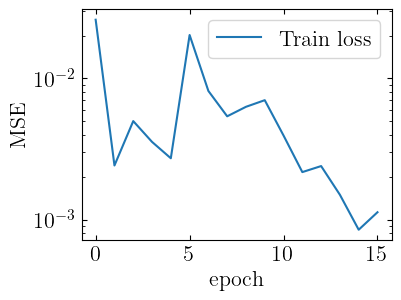

In [230]:
print(history['d_loss'][-1])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.semilogy(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

Test MSE: 5.309e-02


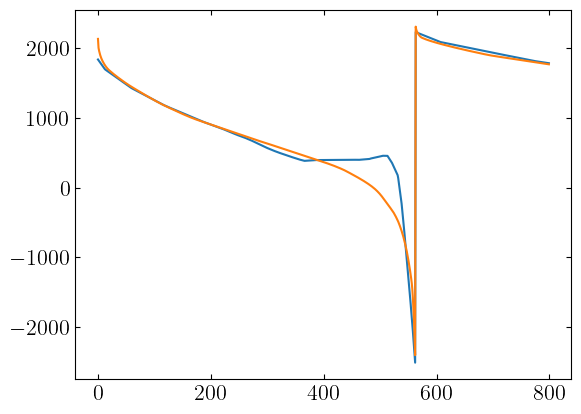

In [241]:
def evaluate(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:,0]
        u = x_test[:,1]
        Ue = x_test[:,2]

        R0_pred, F_pred = model(x_test)
        y_pred = torch.stack([ECM_box(Ue,I,R0_pred), Mech_box(u,F_pred)], dim=1)

        test_loss = nn.MSELoss()(y_pred, y_test).item()
    print(f"Test MSE: {test_loss:.3e}")
    return y_pred, R0_pred, F_pred   


y_pred, R0,F = evaluate(model, x_train, y_train)

#plt.plot(x_test[:,0].numpy()* R0.detach().numpy(), label='Predicted $R_0$')


#plt.plot(y_test[:,0].numpy(), label='True $V_t$')
#plt.plot(y_test[:,1].numpy(), label='ECM $V_t$')
#plt.plot(y_pred[:,1].numpy(), label='Predicted $V_t$')
#plt.plot(-x_train[:,1].numpy() * k.values[0]+ F.detach().numpy(),  label='True $F$')
plt.plot(denormalize(y_pred[:800,0].detach().numpy(),'Rx'), label='Predicted $F$')
plt.plot(denormalize(y_train[:800,0].numpy(),'Rx'), label='True $F$')
